In [1]:
import pandas as pd

df = pd.read_csv("car_price_dataset.csv")
X = df.drop("price", axis=1)
y = df["price"]

In [2]:
df.head()

,engine_size,horsepower,age,mileage,fuel_type,price
0,1623.988261,156.085795,2,55023.36218,0,738786.4575
1,2891.571474,72.880856,8,132564.04730,0,566064.3436
2,2410.386672,136.443254,7,43629.03839,0,892079.0024
3,2117.048665,141.007257,0,115239.39960,0,749733.7487
4,1143.241009,113.619601,10,95466.83490,0,325291.2072


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### L1 (Lasso) :-

In [5]:
from sklearn.linear_model import Lasso, Ridge

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

y_pred_l1 = lasso.predict(X_test)

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

l1_mse = mean_squared_error(y_test, y_pred_l1)
l1_r2 = r2_score(y_test, y_pred_l1)
print("L1 (Lasso) Results :- ")
print("MSE:",l1_mse)
print("R2 Score:",l1_r2)
print("Coefficients:", lasso.coef_)

L1 (Lasso) Results :- 
MSE: 2621716606.9326415
R2 Score: 0.9211678791936496
Coefficients: [  96890.08939858   41856.18133611  -85599.31299828 -110935.18538744
   15386.44364436]


#### L2 (Ridge) -

In [7]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_l2 = ridge.predict(X_test)

In [8]:
l2_mse = mean_squared_error(y_test, y_pred_l2)
l2_r2 = r2_score(y_test, y_pred_l2)
print("L2 (Ridge) Results :- ")
print("MSE:",l2_mse)
print("R2 Score:",l2_r2)
print("Coefficients:", ridge.coef_)

L2 (Ridge) Results :- 
MSE: 2623733837.2279024
R2 Score: 0.9211072233081471
Coefficients: [  96740.98591992   41784.51129654  -85463.10818893 -110773.95424405
   15371.27864039]


C:\Users\hp\AppData\Local\Temp\ipykernel_13700\1035621706.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=Model, y=Values, palette="Blues")


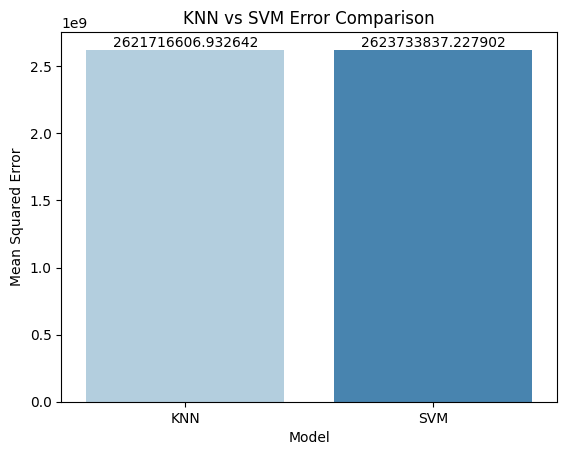

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

Model = ["KNN", "SVM"]
Values = [l1_mse, l2_mse]

plt.figure()
ax = sns.barplot(x=Model, y=Values, palette="Blues")

# Add labels without loop
ax.bar_label(ax.containers[0], fmt="%.6f")
ax.bar_label(ax.containers[1], fmt="%.6f")

plt.title("KNN vs SVM Error Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Squared Error")

plt.show()